In [1]:
import pandas as pd

In [2]:
import requests 

docs_url = 'https://github.com/alexeygrigorev/llm-rag-workshop/raw/main/notebooks/documents.json'
docs_response = requests.get(docs_url)
documents_raw = docs_response.json()

In [3]:
documents = []
for course in documents_raw:
    course_name = course['course']

    for doc in course['documents']:
        doc['course'] = course_name

        documents.append(doc)
        

        

In [4]:
documents[2]

{'text': "Yes, even if you don't register, you're still eligible to submit the homeworks.\nBe aware, however, that there will be deadlines for turning in the final projects. So don't leave everything for the last minute.",
 'section': 'General course-related questions',
 'question': 'Course - Can I still join the course after the start date?',
 'course': 'data-engineering-zoomcamp'}

In [5]:
df = pd.DataFrame(documents, columns = ['course','section','question','text'])

In [6]:
df.head()

,course,section,question,text
0,data-engineering-zoomcamp,General course-related questions,Course - When will the course start?,The purpose of this document is to capture fre...
1,data-engineering-zoomcamp,General course-related questions,Course - What are the prerequisites for this c...,GitHub - DataTalksClub data-engineering-zoomca...
2,data-engineering-zoomcamp,General course-related questions,Course - Can I still join the course after the...,"Yes, even if you don't register, you're still ..."
3,data-engineering-zoomcamp,General course-related questions,Course - I have registered for the Data Engine...,You don't need it. You're accepted. You can al...
4,data-engineering-zoomcamp,General course-related questions,Course - What can I do before the course starts?,You can start by installing and setting up all...


In [7]:
df.tail()

,course,section,question,text
943,mlops-zoomcamp,Module 6: Best practices,Github actions: Permission denied error when e...,Problem description\nThis is the step in the c...
944,mlops-zoomcamp,Module 6: Best practices,Managing Multiple Docker Containers with docke...,Problem description\nWhen a docker-compose fil...
945,mlops-zoomcamp,Module 6: Best practices,AWS regions need to match docker-compose,Problem description\nIf you are having problem...
946,mlops-zoomcamp,Module 6: Best practices,Isort Pre-commit,Problem description\nPre-commit command was fa...
947,mlops-zoomcamp,Module 6: Best practices,How to destroy infrastructure created via GitH...,Problem description\nInfrastructure created in...


In [8]:
df.course.value_counts()

course
data-engineering-zoomcamp    435
machine-learning-zoomcamp    375
mlops-zoomcamp               138
Name: count, dtype: int64

In [9]:
df_ml = df[df.course == 'machine-learning-zoomcamp']

Vector Space

- turn doc into vectors
- term-document matrix:
     - rows : documents
     - columns : words/tokens
- bag of words
     - word order is lost
     - sparse matrix



In [11]:
from sklearn.feature_extraction.text import CountVectorizer


In [12]:
cv = CountVectorizer(min_df = 5)

cv.fit(df.text)


,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [13]:
cv.get_feature_names_out().shape

(1524,)

In [14]:
docs_example = [
    "January course details, register now",
    "Course prerequisites listed in January catalog",
    "Submit January course homework by end of month",
    "Register for January course, no prerequisites",
    "January course setup: Python and Google Cloud"
]


In [15]:
cv2 = CountVectorizer()
cv2.fit(docs_example)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [16]:
cv2.get_feature_names_out()


array(['and', 'by', 'catalog', 'cloud', 'course', 'details', 'end', 'for',
       'google', 'homework', 'in', 'january', 'listed', 'month', 'no',
       'now', 'of', 'prerequisites', 'python', 'register', 'setup',
       'submit'], dtype=object)

In [17]:
X = cv2.transform(docs_example)

In [18]:
pd.DataFrame(X.todense(),columns = cv2.get_feature_names_out()).T


,0,1,2,3,4
and,0,0,0,0,1
by,0,0,1,0,0
catalog,0,1,0,0,0
cloud,0,0,0,0,1
course,1,1,1,1,1
details,1,0,0,0,0
end,0,0,1,0,0
for,0,0,0,1,0
google,0,0,0,0,1
homework,0,0,1,0,0


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer(stop_words = 'english', min_df = 5)

X = cv.fit_transform(df.text)

df_docs = pd.DataFrame(X.toarray(),columns = cv.get_feature_names_out())


In [20]:
df_docs.T.round(2)


,0,1,2,3,4,5,6,7,8,9,...,938,939,940,941,942,943,944,945,946,947
01,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00
02,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00
03,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00
04,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00
05,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
yes,0.0,0.00,0.28,0.0,0.0,0.00,0.21,0.2,0.15,0.00,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00
yml,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.11,0.0,0.0,0.0,0.00
youtube,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.15,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00
zip,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00


In [21]:
X


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23808 stored elements and shape (948, 1333)>

In [22]:
query = "Do I need python to complete this course"

q = cv.transform([query])

q.toarray()

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 1333))

In [23]:
names = cv.get_feature_names_out()
query_dict = dict(zip(names, q.toarray()[0]))

In [24]:
doc_dict = dict(zip(names , X.toarray()[2]))

In [27]:
from sklearn.metrics.pairwise import cosine_similarity


In [28]:
score = cosine_similarity(X,q).flatten()

In [29]:
import numpy as np

np.argsort(score)[-5:]


array([398, 764,  27, 502, 591])

In [30]:
df.iloc[502].text

'It is possible to do the shuffling of the dataset with the pandas built-in function pandas.DataFrame.sample.The complete dataset can be shuffled including resetting the index with the following commands:\nSetting frac=1 will result in returning a shuffled version of the complete Dataset.\nSetting random_state=seed will result in the same randomization as used in the course resources.\ndf_shuffled = df.sample(frac=1, random_state=seed)\ndf_shuffled.reset_index(drop=True, inplace=True)\nAdded by Sylvia Schmitt'

In [31]:
fields = ['section','question','text']


In [32]:
matrices = {}
vectorizers = {}
boosts = {
    'question' : 3 , 
    #'text' : 0.5
}
for f in fields:
    cv = TfidfVectorizer(stop_words = 'english' , min_df = 5)

    X = cv.fit_transform(df[f])
    matrices[f] = X
    vectorizers[f] = cv

    
    

In [33]:
matrices


{'section': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 3090 stored elements and shape (948, 66)>,
 'question': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 3431 stored elements and shape (948, 291)>,
 'text': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 23808 stored elements and shape (948, 1333)>}

In [34]:
vectorizers


{'section': TfidfVectorizer(min_df=5, stop_words='english'),
 'question': TfidfVectorizer(min_df=5, stop_words='english'),
 'text': TfidfVectorizer(min_df=5, stop_words='english')}

In [35]:
n = len(df)


In [36]:
score = np.zeros(n)
query = "Do I need python to complete this course"

q = cv.transform([query])

q.toarray()


for f in fields:
    q = vectorizers[f].transform([query])
    X = matrices[f]

    f_score = cosine_similarity(X,q).flatten()
    boost = boosts.get(f,0)

    score =  score + f_score * boost

In [37]:
filters = {
    'course' : 'machine-learning-zoomcamp'
}

In [38]:
for field,values in filters.items():
    mask = (df[field] == values).astype(int).values
    score = score * mask
    

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [39]:
idx = np.argsort(score)[-5:]

In [40]:
df.iloc[idx]

,course,section,question,text
453,machine-learning-zoomcamp,General course-related questions,What are the deadlines in this course?,"For the 2023 cohort, you can see the deadlines..."
448,machine-learning-zoomcamp,General course-related questions,I’m new to Slack and can’t find the course cha...,Here’s how you join a in Slack: https://slack....
442,machine-learning-zoomcamp,General course-related questions,How much time do I need for this course?,Around ~10 hours per week. Timur Kamaliev did ...
598,machine-learning-zoomcamp,5. Deploying Machine Learning Models,Why do we need the --rm flag,What is the reason we don’t want to keep the d...
510,machine-learning-zoomcamp,2. Machine Learning for Regression,Do we need to apply regularization techniques ...,The application of regularization depends on t...


In [135]:
 class TextSearch:

     def __init__(self, text_fields):
         self.text_fields = text_fields
         self.matrices = {}
         self.vectorizers = {}

     def fit(self , records , vectorizer_params = {}):
         self.df = pd.DataFrame(records)
         for f in self.text_fields:
             cv = TfidfVectorizer(**vectorizer_params)
             X = cv.fit_transform(self.df[f])
             self.matrices[f] = X
             self.vectorizers[f] = cv
                
     def search(self , query , n_results = 5 , boost = {} , filters = {}):
         score = np.zeros(len(self.df))
         for f in self.text_fields:
             b = boost.get(f,1.0)
             q = self.vectorizers[f].transform([query])
             s = cosine_similarity(self.matrices[f] , q).flatten()
             score = score + b * s
    
         for field , value in filters.items():
             mask = (self.df[field] == value).astype(int).values
             score = score * mask
    
         idx = np.argsort(-score)[:n_results]
         results = self.df.iloc[idx]
         return results.to_dict(orient = 'records')

In [136]:
fields

['section', 'question', 'text']

In [137]:
index = TextSearch(text_fields = ['section','question','text'])


In [138]:

index.fit(documents)

In [139]:
index.search(query = 'is this live?' , 
             n_results = 5 , 
             boost = {'question' : 3} , 
             filters = {'course' : 'machine-learning-zoomcamp'})

[{'text': 'The course videos are pre-recorded, you can start watching the course right now.\nWe will also occasionally have office hours - live sessions where we will answer your questions. The office hours sessions are recorded too.\nYou can see the office hours as well as the pre-recorded course videos in the course playlist on YouTube.',
  'section': 'General course-related questions',
  'question': 'Is it going to be live? When?',
  'course': 'machine-learning-zoomcamp'},
 {'text': 'For the 2023 cohort, you can see the deadlines here (it’s taken from the 2023 cohort page)',
  'section': 'General course-related questions',
  'question': 'What are the deadlines in this course?',
  'course': 'machine-learning-zoomcamp'},
 {'text': 'Around ~10 hours per week. Timur Kamaliev did a detailed analysis of how much time students of the previous cohort needed to spend on different modules and projects. Full article',
  'section': 'General course-related questions',
  'question': 'How much tim

In [90]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23808 stored elements and shape (948, 1333)>

In [93]:
matrices['text']

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23808 stored elements and shape (948, 1333)>

In [95]:
from sklearn.decomposition import TruncatedSVD

X = matrices['text']
cv = vectorizers['text']

In [96]:
cv

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.

In [106]:
svd = TruncatedSVD(n_components = 15)

X_emb = svd.fit_transform(X)

In [107]:
X_emb.shape

(948, 15)

In [109]:
query = 'I just signed up .. Is it possibel to complete in 1 week?'

q = cv.transform([query])

Q_emb = svd.transform(q)

Q_emb[0]

array([ 0.04885475, -0.01841391, -0.02942799, -0.01385425,  0.02997521,
       -0.0249308 ,  0.00056244, -0.02162492, -0.02752018,  0.037436  ,
       -0.00122307,  0.01431644, -0.02598186,  0.00947162,  0.01458828])

In [115]:
np.dot(X_emb[0], Q_emb[0]).flatten()

array([0.03840096])

In [116]:
scores = cosine_similarity(X_emb,Q_emb).flatten()

idx = np.argsort(-scores)[:10]

In [118]:
list(df.iloc[idx].text)

['When you post about what you learned from the course on your social media pages, use the tag #mlzoomcamp. When you submit your homework, there’s a section in the form for putting the links there. Separate multiple links by any whitespace character (linebreak, space, tab, etc).\nFor posting the learning in public links, you get extra scores. But the number of scores is limited to 7 points: if you put more than 7 links in your homework form, you’ll get only 7 points.\nThe same content can be posted to 7 different social sites and still earn you 7 points if you add 7 URLs per week, see Alexey’s reply. (~ ellacharmed)\nFor midterms/capstones, the awarded points are doubled as the duration is longer. So for projects the points are capped at 14 for 14 URLs.',
 'After you submit your homework it will be graded based on the amount of questions in a particular homework. You can see how many points you have right on the page of the homework up top. Additionally in the leaderboard you will find

In [128]:
from sklearn.decomposition import NMF
nmf = NMF(n_components = 16)
X_emb = nmf.fit_transform(X)

X_emb[0]

array([0.12704579, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.00084317, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ])

In [133]:
query = 'Is it live? '

q = cv.transform([query])

Q_emb = nmf.transform(q)


In [134]:
scores = cosine_similarity(X_emb, Q_emb).flatten()

idx = np.argsort(-scores)[:10]

df.iloc[idx]

,course,section,question,text
449,machine-learning-zoomcamp,General course-related questions,The course has already started. Can I still jo...,"Yes, you can. You won’t be able to submit some..."
764,machine-learning-zoomcamp,Projects (Midterm and Capstone),What If I submitted only two projects and fail...,If you have submitted two projects (and peer-r...
2,data-engineering-zoomcamp,General course-related questions,Course - Can I still join the course after the...,"Yes, even if you don't register, you're still ..."
814,mlops-zoomcamp,+-General course questions,What if my answer is not exactly the same as t...,Please choose the closest one to your answer. ...
11,data-engineering-zoomcamp,General course-related questions,Certificate - Can I follow the course in a sel...,"No, you can only get a certificate if you fini..."
436,machine-learning-zoomcamp,General course-related questions,Is it going to be live? When?,"The course videos are pre-recorded, you can st..."
0,data-engineering-zoomcamp,General course-related questions,Course - When will the course start?,The purpose of this document is to capture fre...
451,machine-learning-zoomcamp,General course-related questions,Can I submit the homework after the due date?,"No, it’s not possible. The form is closed afte..."
437,machine-learning-zoomcamp,General course-related questions,What if I miss a session?,"Everything is recorded, so you won’t miss anyt..."
7,data-engineering-zoomcamp,General course-related questions,Course - Can I follow the course after it fini...,"Yes, we will keep all the materials after the ..."


## Create Embeddings with Bert

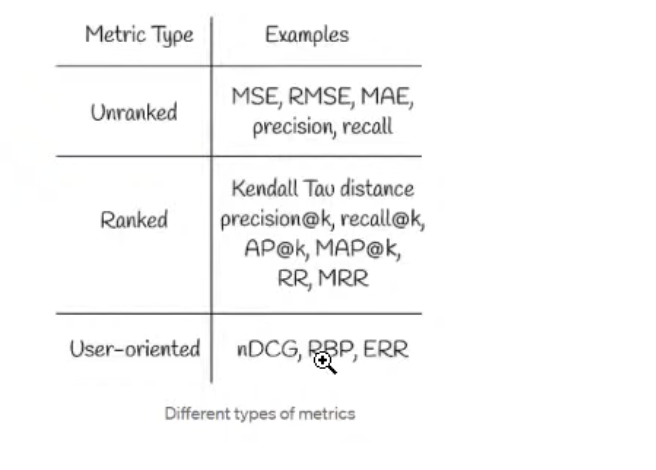

In [151]:
import torch
from transformers import BertModel , BertTokenizer

model = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model)
model = BertModel.from_pretrained(model)

#Put the model in eval for inference and not training

model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [143]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [154]:
texts = [
    "Where Can I find help if I get stuck?" , 
     "You can follow the course on your own pace after it finishes "]


encoded_input = tokenizer(texts , padding = True , truncation = True , return_tensors="pt")

In [155]:
with torch.no_grad(): #Disable gradient calculation for Inference
    outputs = model(**encoded_input)
    hidden_states = outputs.last_hidden_state

In [159]:
hidden_states[0].shape

torch.Size([14, 768])

In [163]:
#We take average

sentence_embeddings  = hidden_states.mean(dim = 1)
sentence_embeddings.shape

torch.Size([2, 768])

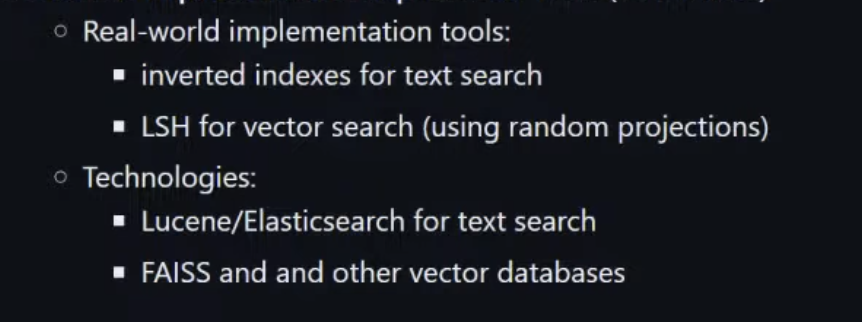